In [336]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from matplotlib import pyplot as plt
import seaborn as sns
import time
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from torch.utils.data.dataloader import DataLoader
from torch.utils.data.dataset import TensorDataset

plt.style.use("default")

In [337]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [338]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False) # X: (70000, 784)

In [339]:
X, y = mnist["data"], mnist["target"]
X = torch.Tensor(X.astype(np.float32) / 255.0).reshape(-1, 1, 28, 28)
y = torch.Tensor(y.astype(np.int64))
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=10000, random_state=42, stratify=y
)
X_test = X_test.to(device)

In [340]:
X_trainval.shape

torch.Size([60000, 1, 28, 28])

In [341]:
train_dataset = TensorDataset(X_trainval.to(device), y_trainval.to(device))
test_dataset = TensorDataset(X_test.to(device), y_test.to(device))

test_loader = DataLoader(test_dataset, batch_size=1000)

In [342]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()

        # Thanx to https://medium.com/data-science-collective/implementing-cnn-in-pytorch-testing-on-mnist-99-26-test-accuracy-5c63876c6ac8
        self.model = nn.Sequential(
            nn.ZeroPad2d(2),
            nn.Conv2d(1, 16, 5, 1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.LazyLinear(out_features=10),
        )

        self.train_loss_per_epoch = None
        self.val_loss_per_batch = None
        self.best_val_loss = None

    def forward(self, x):
        x = self.model(x)
        return x


In [343]:
def train_one_model(max_epochs: int, batch_size: int, lr: float) -> MLP:
    model = MLP()
    model.to(device)
    model.train()

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    loss_fn = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    n_reports = 10
    print_every = max(max_epochs // n_reports, 1)

    train_loss_per_epoch = np.zeros(max_epochs)
    val_loss_per_batch = np.zeros(max_epochs)

    for epoch in range(max_epochs):
        for data, target in train_loader:
            optimizer.zero_grad()

            y_pred = model(data)

            loss = loss_fn(y_pred, target.long())
            loss.backward()

            optimizer.step()

        model.eval()

        with torch.no_grad():
            loss = 0.0

            for data, target in train_loader:
                y_pred = model(data)
                loss += loss_fn(y_pred, target.long()).item()

            loss_avg = loss / len(train_loader)
            train_loss_per_epoch[epoch] = loss_avg

            loss = 0.0

            for data, target in test_loader:
                y_pred = model(data)
                loss += loss_fn(y_pred, target.long()).item()

            loss_avg = loss / len(test_loader)
            val_loss_per_batch[epoch] = loss_avg

            # if epoch % print_every == 0:
            #     print(f"{epoch=}\tCrossEntropy = {loss_avg:.3f}")

        model.train()

    model.train_loss_per_epoch = train_loss_per_epoch
    model.val_loss_per_batch = val_loss_per_batch
    model.best_val_loss = np.min(val_loss_per_batch).item()

    model.eval()
    return model

In [344]:
batch_sizes = [
    4096,
    2048,
    1024,
    512,
    256,
    128,
    64,
    32,
    16,
    8,
]

learning_rates = [
    0.00001,
    0.0001,
    0.001,
    0.01,
    0.1,
]

RUNS = 5
losses = np.zeros((RUNS, len(batch_sizes), len(learning_rates)), dtype=float)
training_durations = np.zeros_like(losses, dtype=float)

for run in range(RUNS):
    for i, batch_size in enumerate(batch_sizes):
        for j, lr in enumerate(learning_rates):
            lr = 0.1

            start = time.time()
            model = train_one_model(5, batch_size, lr)
            duration = time.time() - start

            losses[run, i, j] = model.best_val_loss
            training_durations[run, i, j] = duration

            perc_done = 100*(i*models.shape[1] + j + 1)//models.size
            print(f"[{perc_done:3n}%] model ({i}, {j}) trained with best val loss = {model.best_val_loss}")

    print(f"Run {run+1}/{RUNS} done\n")

/home/dom/python_global_venvs/ML/venv/lib64/python3.11/site-packages/torch/nn/modules/lazy.py:181: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


[  2%] model (0, 0) trained with best val loss = 2.2888540267944335
[  4%] model (0, 1) trained with best val loss = 0.31423992812633517
[  6%] model (0, 2) trained with best val loss = 1.1019436359405517
[  8%] model (0, 3) trained with best val loss = 0.33683812618255615
[ 10%] model (0, 4) trained with best val loss = 2.1878751039505007
[ 12%] model (1, 0) trained with best val loss = 0.3707808583974838
[ 14%] model (1, 1) trained with best val loss = 0.17313235700130464
[ 16%] model (1, 2) trained with best val loss = 2.301281237602234
[ 18%] model (1, 3) trained with best val loss = 0.8038978993892669
[ 20%] model (1, 4) trained with best val loss = 0.32491974234580995
[ 22%] model (2, 0) trained with best val loss = 0.3017975211143494
[ 24%] model (2, 1) trained with best val loss = 0.2638188362121582
[ 26%] model (2, 2) trained with best val loss = 0.2138066053390503
[ 28%] model (2, 3) trained with best val loss = 0.30472423136234283
[ 30%] model (2, 4) trained with best val lo

In [345]:
losses.reshape(-1, 5)

array([[2.28885403, 0.31423993, 1.10194364, 0.33683813, 2.1878751 ],
       [0.37078086, 0.17313236, 2.30128124, 0.8038979 , 0.32491974],
       [0.30179752, 0.26381884, 0.21380661, 0.30472423, 0.24957165],
       [2.30206754, 0.12848798, 0.29953579, 0.13616266, 0.28876628],
       [0.28287853, 0.27074643, 0.15085071, 0.13330361, 2.30340986],
       [0.1359215 , 0.27118455, 0.29351124, 0.18664493, 0.26501366],
       [0.27987688, 2.30772016, 0.32013883, 0.32582179, 0.31625678],
       [2.30855689, 2.30573363, 2.30779734, 2.30386689, 0.29578118],
       [2.31789823, 0.37198358, 2.31348782, 0.42659903, 2.31436505],
       [2.30844142, 2.31346927, 2.31695063, 2.31293285, 2.3176096 ],
       [0.43582713, 2.27675405, 2.30118091, 0.34867032, 0.35043894],
       [0.34396115, 0.21971739, 0.44556523, 0.34358115, 2.30127854],
       [0.37810814, 0.22022004, 0.28972082, 2.30167613, 0.14642899],
       [2.30164533, 2.30183589, 0.13251409, 0.23038395, 0.26597211],
       [0.27195736, 0.15262536, 2.

In [346]:
# Appends the results to the CSV
try:
    df = pd.read_csv("batch_size_losses.csv", header=None)
    df = pd.concat([df, pd.DataFrame(losses.reshape(-1, 5))], axis=0)
except FileNotFoundError:
    df = pd.DataFrame(losses)

df.to_csv("batch_size_losses.csv", index=False, header=False)
df

,0,1,2,3,4
0,0.374597,2.301324,0.956208,2.265458,2.301165
1,0.247205,0.387024,2.301224,0.347141,0.464161
2,0.189536,0.293295,2.301641,0.150651,0.323434
3,0.321447,0.275515,0.266691,0.148513,0.286127
4,2.303589,0.153664,0.303408,0.266169,0.136136
...,...,...,...,...,...
45,0.243217,0.151631,0.127187,0.283429,0.283862
46,0.304533,0.287315,0.292504,0.292827,0.306397
47,2.305365,0.309952,0.271798,2.309338,2.303439
48,0.357673,0.326068,2.316164,0.386749,0.387458


In [347]:
# Averaging
losses_combined = np.stack([df[i:i+10] for i in range(0, len(df), 10)])
losses = losses_combined.mean(axis=0)
losses_combined.shape

(10, 10, 5)

<Axes: >

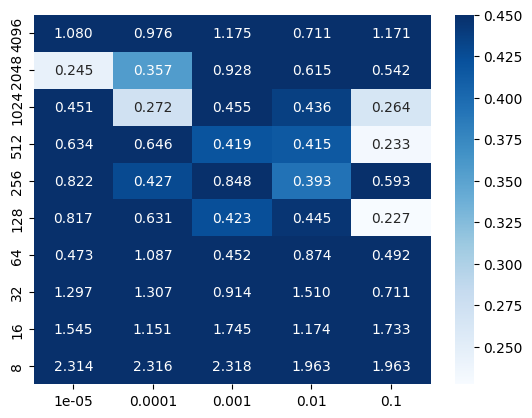

In [348]:
sns.heatmap(losses, annot=True, vmax=0.45, fmt=".3f", xticklabels=learning_rates, yticklabels=batch_sizes, cmap="Blues")

<Axes: >

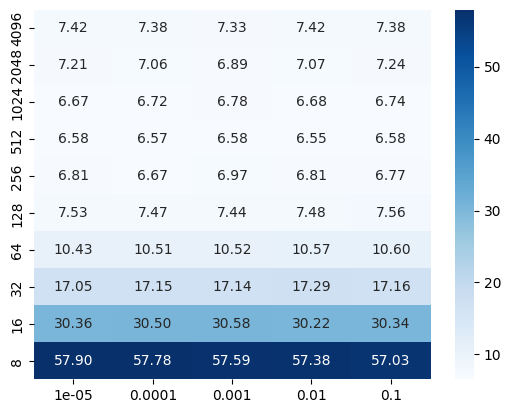

In [349]:
training_durations = training_durations.mean(axis=0)
sns.heatmap(training_durations, annot=True, fmt=".2f", xticklabels=learning_rates, yticklabels=batch_sizes, cmap="Blues")

In [350]:
inv_training_eff = losses*training_durations

inv_training_eff

array([[  8.01632981,   7.19849052,   8.6117461 ,   5.2724368 ,
          8.63281939],
       [  1.76387587,   2.52114436,   6.3910562 ,   4.34812255,
          3.92787064],
       [  3.00757439,   1.83005356,   3.08350752,   2.91314229,
          1.77988154],
       [  4.17225437,   4.24369686,   2.757881  ,   2.71944504,
          1.52894429],
       [  5.59504929,   2.85026656,   5.90994183,   2.67702476,
          4.0115538 ],
       [  6.15030426,   4.71453662,   3.15101872,   3.33406794,
          1.7192863 ],
       [  4.9280518 ,  11.42130489,   4.75796992,   9.23676861,
          5.22025138],
       [ 22.11386994,  22.41385435,  15.66027134,  26.11889637,
         12.19892278],
       [ 46.91390749,  35.09748883,  53.3625154 ,  35.4730271 ,
         52.57054544],
       [133.97673734, 133.81890796, 133.50298268, 112.63401713,
        111.9402107 ]])

<Axes: >

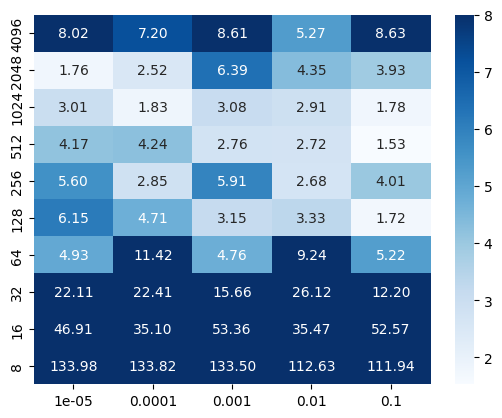

In [351]:
sns.heatmap(inv_training_eff, annot=True, vmax=8, fmt=".2f", xticklabels=learning_rates, yticklabels=batch_sizes, cmap="Blues")

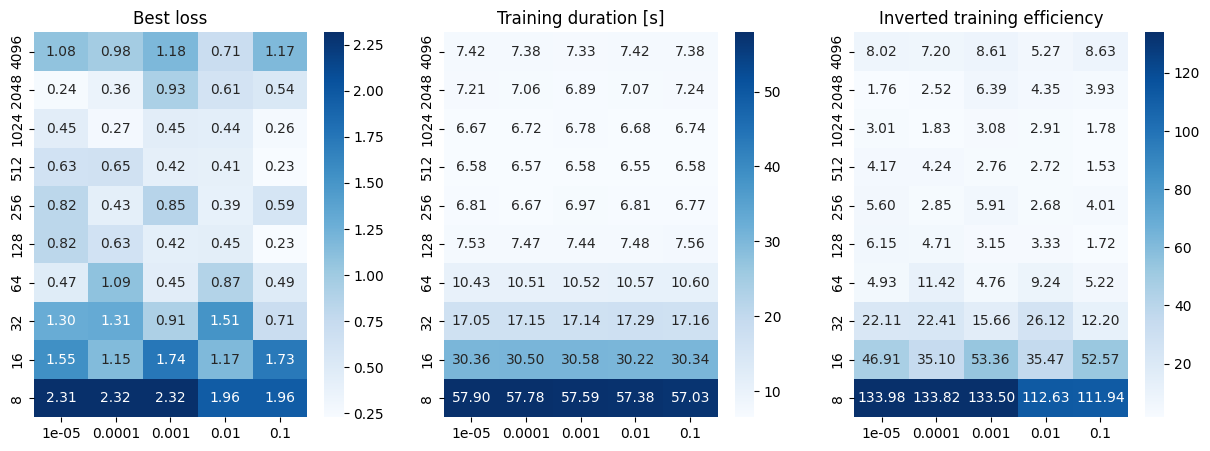

In [352]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

titles = ["Best loss", "Training duration [s]", "Inverted training efficiency"]
for ax, arr, title in zip(axs, [losses, training_durations, inv_training_eff], titles):
    sns.heatmap(arr, annot=True, fmt=".2f", xticklabels=learning_rates, yticklabels=batch_sizes, cmap="Blues", ax=ax)
    ax.set_title(title)

plt.show()
